Apply rotation, scaling, and shearing to a unit square (corners at [0,0], [1,0], [1,1], [0,1]). Print the transformed corners for each. Verify that rotation preserves distances between corners.


Original unit square:
  corner 0: (0.0000, 0.0000)
  corner 1: (1.0000, 0.0000)
  corner 2: (1.0000, 1.0000)
  corner 3: (0.0000, 1.0000)

Rotated by 30°:
  corner 0: (0.0000, 0.0000)
  corner 1: (0.8660, 0.5000)
  corner 2: (0.3660, 1.3660)
  corner 3: (-0.5000, 0.8660)

Rotation preserves distances? True
Max distance error: 1.1102230246251565e-16

Scaled (sx=2, sy=0.5):
  corner 0: (0.0000, 0.0000)
  corner 1: (2.0000, 0.0000)
  corner 2: (2.0000, 0.5000)
  corner 3: (0.0000, 0.5000)

Sheared (kx=0.5):
  corner 0: (0.0000, 0.0000)
  corner 1: (1.0000, 0.0000)
  corner 2: (1.5000, 1.0000)
  corner 3: (0.5000, 1.0000)


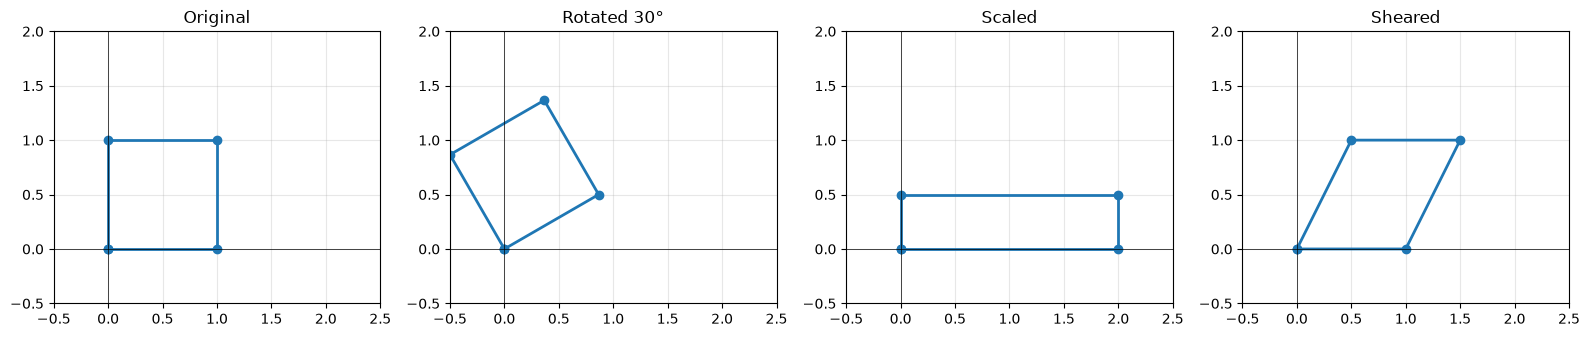

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def apply_transformation(square, matrix):
    """Apply a 2x2 transformation matrix to square corners.
    
    square: (4, 2) array of corner coordinates (rows are points)
    matrix: (2, 2) transformation matrix
    Returns: (4, 2) transformed corners
    """
    return square @ matrix.T   # (4,2) @ (2,2) -> (4,2)

def print_corners(name, corners):
    print(f"\n{name}:")
    for i, (x, y) in enumerate(corners):
        print(f"  corner {i}: ({x:.4f}, {y:.4f})")

def pairwise_distances(points):
    """Return matrix of distances between all pairs of points."""
    diff = points[:, None, :] - points[None, :, :]   # (N,N,2)
    return np.linalg.norm(diff, axis=-1)             # (N,N)

# --- Unit square corners (counter-clockwise) ---
square = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])

print_corners("Original unit square", square)
orig_dists = pairwise_distances(square)

# ---------------------------------------------------------------
# 1. ROTATION  (preserves distances — orthogonal matrix, det = +1)
# ---------------------------------------------------------------
theta = np.deg2rad(30)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])
rotated = apply_transformation(square, R)
print_corners(f"Rotated by {np.rad2deg(theta):.0f}°", rotated)

# Verify distances are preserved
rot_dists = pairwise_distances(rotated)
print("\nRotation preserves distances?",
      np.allclose(orig_dists, rot_dists, atol=1e-10))
print("Max distance error:", np.abs(orig_dists - rot_dists).max())

# ---------------------------------------------------------------
# 2. SCALING  (does NOT preserve distances)
# ---------------------------------------------------------------
S = np.array([
    [2.0, 0.0],   # scale x by 2
    [0.0, 0.5],   # scale y by 0.5
])
scaled = apply_transformation(square, S)
print_corners("Scaled (sx=2, sy=0.5)", scaled)

# ---------------------------------------------------------------
# 3. SHEARING  (does NOT preserve distances)
# ---------------------------------------------------------------
H = np.array([
    [1.0, 0.5],   # horizontal shear
    [0.0, 1.0],
])
sheared = apply_transformation(square, H)
print_corners("Sheared (kx=0.5)", sheared)

# ---------------------------------------------------------------
# Optional: visualize
# ---------------------------------------------------------------
def close_poly(c):
    return np.vstack([c, c[:1]])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, pts) in zip(axes, [
    ("Original", square), ("Rotated 30°", rotated),
    ("Scaled", scaled), ("Sheared", sheared)
]):
    p = close_poly(pts)
    ax.plot(p[:, 0], p[:, 1], 'o-', lw=2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 2.0)

plt.tight_layout()
plt.show()

Find the eigenvalues of the matrix [[4, 2], [1, 3]] by hand using the characteristic equation. Then verify with your from-scratch function and with NumPy.

In [3]:
A=np.array([[4,2],[1,3]])
np.linalg.eig(A)

EigResult(eigenvalues=array([5.+0.j, 2.+0.j]), eigenvectors=array([[ 0.89442719+0.j, -0.70710678+0.j],
       [ 0.4472136 +0.j,  0.70710678+0.j]]))

Create a composition of three transformations (rotate 30 degrees, scale by [1.5, 0.8], shear with kx=0.3) and apply it to 8 points arranged in a circle. Print before and after coordinates. Compute the determinant of the composed matrix and verify it equals the product of the individual determinants.

Composed matrix M = H @ S @ R:
[[ 1.41903811 -0.5421539 ]
 [ 0.4         0.69282032]]

idx |        before (x, y) |         after (x, y)
----------------------------------------------------
  0 | ( 1.0000,  0.0000) | ( 1.4190,  0.4000)
  1 | ( 0.7071,  0.7071) | ( 0.6201,  0.7727)
  2 | ( 0.0000,  1.0000) | (-0.5422,  0.6928)
  3 | (-0.7071,  0.7071) | (-1.3868,  0.2071)
  4 | (-1.0000,  0.0000) | (-1.4190, -0.4000)
  5 | (-0.7071, -0.7071) | (-0.6201, -0.7727)
  6 | (-0.0000, -1.0000) | ( 0.5422, -0.6928)
  7 | ( 0.7071, -0.7071) | ( 1.3868, -0.2071)

Determinants:
  det(R)          = 1.0000000000
  det(S)          = 1.2000000000
  det(H)          = 1.0000000000
  det(M)          = 1.2000000000
  det(R)*det(S)*det(H) = 1.2000000000
  Match? True


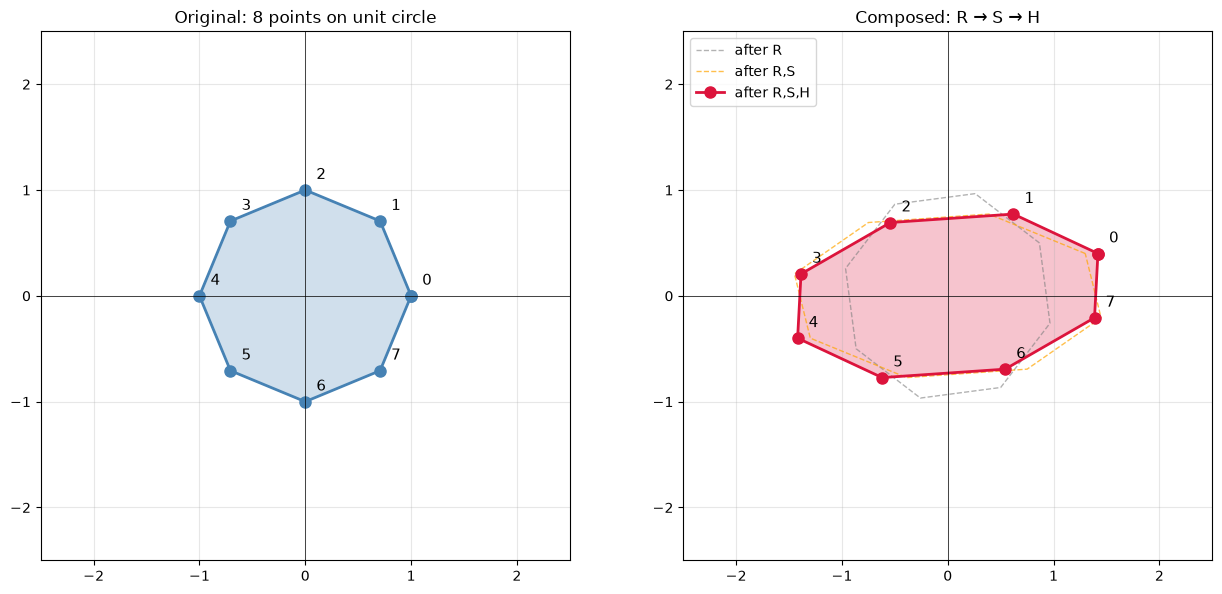

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Build individual transformation matrices (2x2)
# ---------------------------------------------------------------
theta = np.deg2rad(30)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])          # rotation

S = np.array([[1.5, 0.0],
              [0.0, 0.8]])                                # scaling

H = np.array([[1.0, 0.3],                                 # shear (kx = 0.3)
              [0.0, 1.0]])

# ---------------------------------------------------------------
# 2. Compose: apply R first, then S, then H
#    For row vectors:  p' = p @ R.T @ S.T @ H.T
#    So the composed matrix (in column convention) is:  M = H @ S @ R
# ---------------------------------------------------------------
M = H @ S @ R
print("Composed matrix M = H @ S @ R:")
print(M)
print()

# ---------------------------------------------------------------
# 3. Generate 8 points on a unit circle
# ---------------------------------------------------------------
n = 8
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
points = np.column_stack([np.cos(angles), np.sin(angles)])   # (8, 2)

# ---------------------------------------------------------------
# 4. Apply the composed transformation
# ---------------------------------------------------------------
transformed = points @ M.T                                    # (8, 2)

# ---------------------------------------------------------------
# 5. Print before and after
# ---------------------------------------------------------------
print(f"{'idx':>3} | {'before (x, y)':>20} | {'after (x, y)':>20}")
print("-" * 52)
for i in range(n):
    bx, by = points[i]
    ax, ay = transformed[i]
    print(f"{i:>3} | ({bx:>7.4f}, {by:>7.4f}) | ({ax:>7.4f}, {ay:>7.4f})")

# ---------------------------------------------------------------
# 6. Determinant verification
# ---------------------------------------------------------------
det_R = np.linalg.det(R)
det_S = np.linalg.det(S)
det_H = np.linalg.det(H)
det_M = np.linalg.det(M)

print("\nDeterminants:")
print(f"  det(R)          = {det_R:.10f}")
print(f"  det(S)          = {det_S:.10f}")
print(f"  det(H)          = {det_H:.10f}")
print(f"  det(M)          = {det_M:.10f}")
print(f"  det(R)*det(S)*det(H) = {det_R * det_S * det_H:.10f}")
print(f"  Match? {np.isclose(det_M, det_R * det_S * det_H)}")

# ---------------------------------------------------------------
# 7. Visualization
# ---------------------------------------------------------------
def close_poly(pts):
    return np.vstack([pts, pts[:1]])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# -- Left: original --
ax = axes[0]
p = close_poly(points)
ax.fill(p[:, 0], p[:, 1], alpha=0.25, color='steelblue')
ax.plot(p[:, 0], p[:, 1], 'o-', color='steelblue', lw=2, ms=8)
for i, (x, y) in enumerate(points):
    ax.annotate(str(i), (x, y), textcoords="offset points",
                xytext=(8, 8), fontsize=11)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Original: 8 points on unit circle")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

# -- Right: transformed, with intermediate steps faded --
ax = axes[1]

# intermediate: after rotation only
p_R = points @ R.T
pr = close_poly(p_R)
ax.plot(pr[:, 0], pr[:, 1], '--', color='gray',
        lw=1, alpha=0.6, label='after R')

# intermediate: after R then S
p_RS = points @ R.T @ S.T
prs = close_poly(p_RS)
ax.plot(prs[:, 0], prs[:, 1], '--', color='orange',
        lw=1, alpha=0.7, label='after R,S')

# final: full composition
pt = close_poly(transformed)
ax.fill(pt[:, 0], pt[:, 1], alpha=0.25, color='crimson')
ax.plot(pt[:, 0], pt[:, 1], 'o-', color='crimson', lw=2, ms=8,
        label='after R,S,H')
for i, (x, y) in enumerate(transformed):
    ax.annotate(str(i), (x, y), textcoords="offset points",
                xytext=(8, 8), fontsize=11)

ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_title("Composed: R → S → H")
ax.legend(loc='upper left')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)

plt.tight_layout()
plt.show()